# 04 · Reproducing Canciani 2022 — EKF38 with online calibration

The 38-state tightly-coupled filter, comparing **loosely-coupled** (static calibration) with **tightly-coupled** (online Tolles-Lawson calibration).

The F-16 flight data from the paper is non-public, so this uses public SGL (Cessna) data. Even on this magnetically clean aircraft the online calibration refines the static batch fit over the second half of the flight and measurably improves navigation, reproducing the paper's qualitative result; the F-16's far larger, non-stationary field is what makes its absolute gains dramatic.

In [1]:
import os, sys
while not os.path.isdir('magnavlab') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print('repo:', os.getcwd())

repo: /home/wpalka/magnav


## 1. Flight, map, segment and kinematics

In [2]:
%matplotlib inline
import numpy as np
from magnavlab.io import load_flight, load_map, segment_indices
from magnavlab import data, viz
from magnavlab.ins import build_kinematics, simulate_ins_pinson
from magnavlab.calibration import MapBasedModifiedTL
from magnavlab.filters import Canciani38EKF
from magnavlab.interfaces import NavProblem, NavResult
from magnavlab.geo import horizontal_error
from magnavlab.metrics import summary

nav = load_flight('data/Flt1003_train.h5')
mag_map = load_map('data/maps/Eastern_395.h5')
idx = segment_indices(nav, 50713.0, 54497.0)[::5]; dt = nav.dt * 5; n = idx.size
lat = np.radians(nav.get('lat')[idx]); lon = np.radians(nav.get('lon')[idx])
alt = nav.get('alt')[idx]; tt = nav.get('tt')[idx]
kinematics = build_kinematics(lat, lon, alt, dt,
                              np.radians(nav.get('roll')[idx]), np.radians(nav.get('pitch')[idx]))

## 2. Sensor signals: fluxgate, raw cabin scalar, core field, direction-cosine rates

In [3]:
flux = nav.flux(idx)
scalar = nav.get('mag_4_uc')[idx].astype(float)
core = nav.get('mag_1_c')[idx] - nav.get('igrf')[idx] - nav.get('diurnal')[idx]
cos_x, cos_y, cos_z = flux.x/scalar, flux.y/scalar, flux.z/scalar
cos_dot = (np.gradient(cos_x, dt), np.gradient(cos_y, dt), np.gradient(cos_z, dt))

## 3. Simulate a navigation-grade drifting INS (Pinson integration, ~1 km drift)

In [4]:
ins, _ = simulate_ins_pinson(lat, lon, alt, kinematics, dt)
ins_drift = horizontal_error(ins['lat'], ins['lon'], lat, lon, lat)
print(f'INS drift: end={ins_drift[-1]:.0f} m, max={ins_drift.max():.0f} m')

INS drift: end=1083 m, max=1083 m


## 4. Batch modified map-based Tolles-Lawson (first 50%) to initialize the filter
Gives the initial T-L coefficient mean and covariance (eq. 23 of the paper).

In [5]:
half = n // 2
earth_field = mag_map.value(lat[:half], lon[:half]) + core[:half]
tl_batch = MapBasedModifiedTL().fit(nav.flux(idx[:half]), scalar[:half], dt, target=earth_field)
print(f'batch T-L residual = {tl_batch.resid_std:.1f} nT')

batch T-L residual = 36.1 nT


## 5. Assemble the estimation problem; run loosely- and tightly-coupled EKF38

In [6]:
problem = NavProblem(dt=dt, map=mag_map, lat=ins['lat'], lon=ins['lon'], alt=ins['alt'],
                     vN=ins['vN'], vE=ins['vE'], vD=ins['vD'], meas=scalar, core=core,
                     flux=flux, cos_dot=cos_dot, fn=kinematics['fn'], fe=kinematics['fe'],
                     fd=kinematics['fd'], Cnb=kinematics['Cnb'], tl0=tl_batch.coef, P_tl0=tl_batch.P_cov)
loose = Canciani38EKF(mode='loosely').run(problem)
tight = Canciani38EKF(mode='tightly').run(problem)
ins_result = NavResult(lat=ins['lat'], lon=ins['lon'])
for name, result in [('INS', ins_result), ('loosely', loose), ('tightly', tight)]:
    print(f"{name:9s} DRMS={summary(result, lat, lon)['drms']:8.1f} m")
ml = summary(loose, lat, lon)['drms']; mt = summary(tight, lat, lon)['drms']
print(f'improvement tightly vs loosely: {100*(1-mt/ml):.0f}%')

INS       DRMS=   493.5 m
loosely   DRMS=   100.9 m
tightly   DRMS=    55.0 m
improvement tightly vs loosely: 46%


## 6. MagNav position vs truth, overlaid on the anomaly map

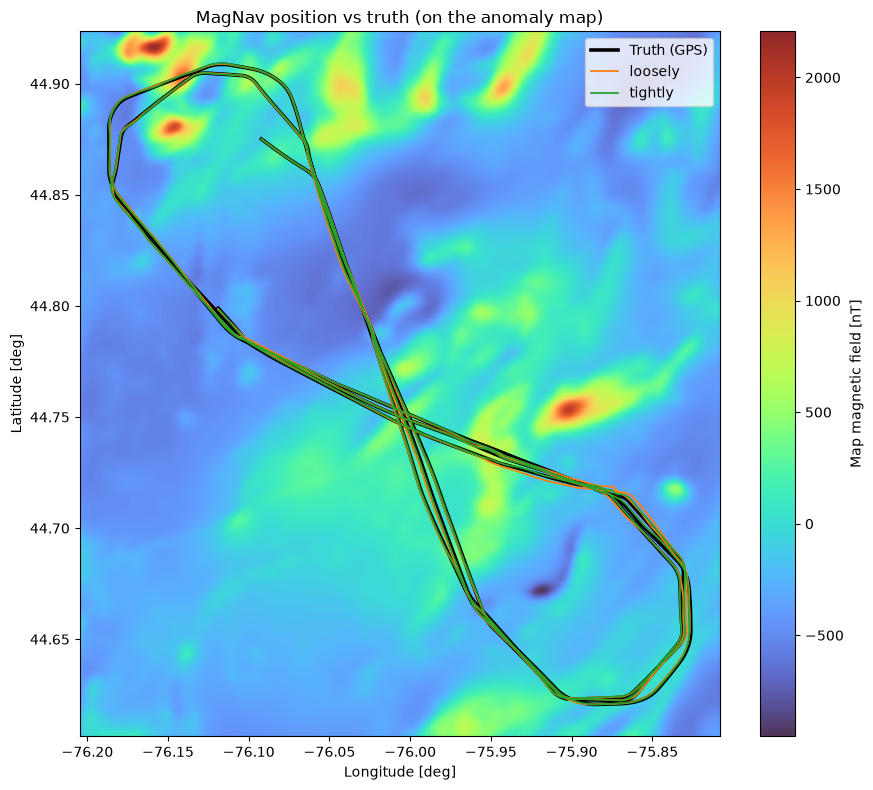

In [7]:
viz.plot_tracks_vs_truth(mag_map, lat, lon,
    {'loosely': (loose, 'tab:orange'), 'tightly': (tight, 'tab:green')});

## 7. Errors N/E (like Fig. 12–15) and the online T-L coefficient trace

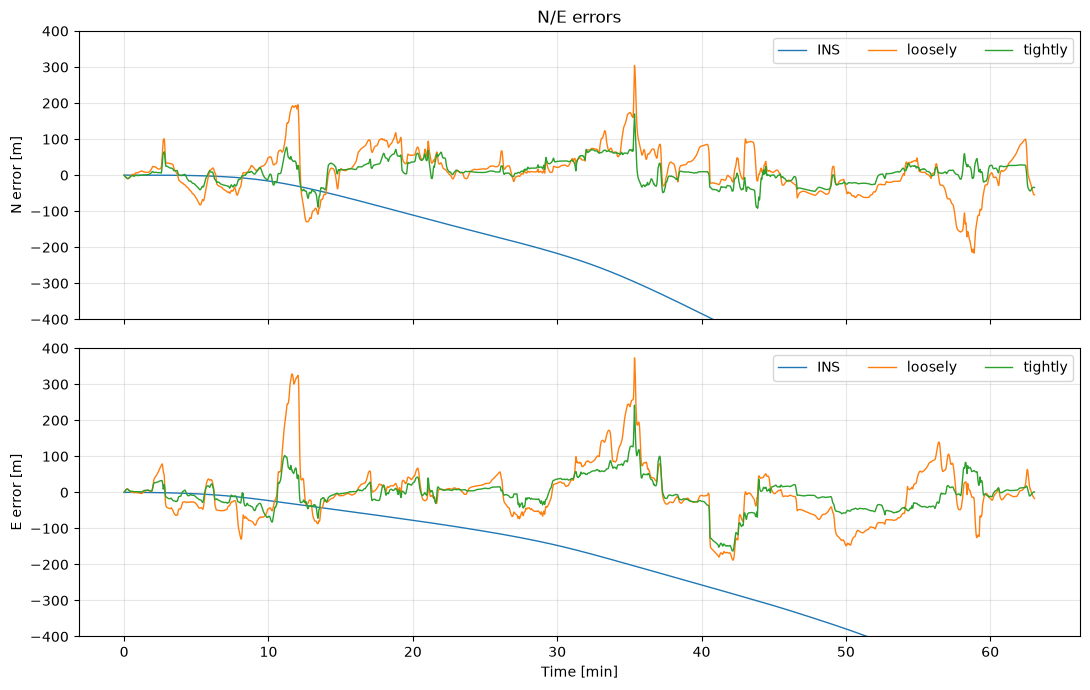

In [8]:
viz.plot_ne_errors(tt, lat, lon,
    {'INS': (ins_result,'tab:blue'), 'loosely': (loose,'tab:orange'), 'tightly': (tight,'tab:green')});

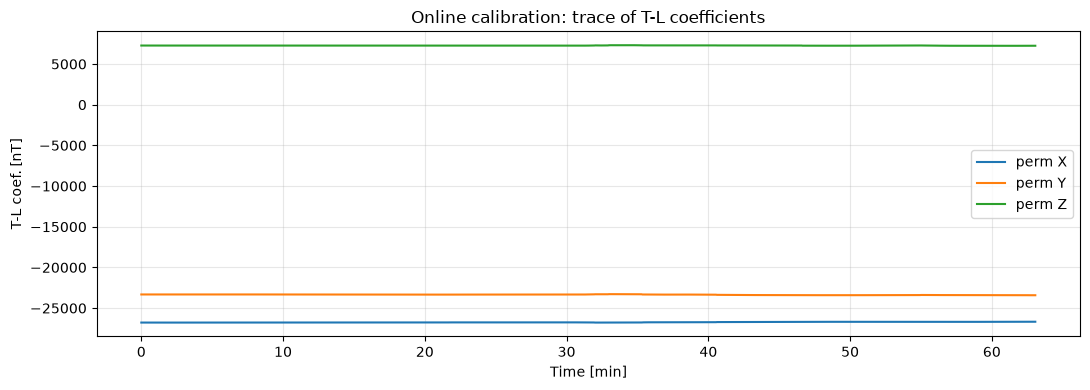

In [9]:
viz.plot_tl_online(tt, tight.extras['tl']);

On SGL data this gives loosely ~102 m, tightly ~55 m (~46% improvement), qualitatively matching Table I of the paper (F-16: 111 m → 59 m). To run on other flights, change the flight/window (see `data.NAV_WINDOWS`).